In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [3]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [4]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [5]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [6]:
print(df.columns)

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')


In [7]:
df.columns.tolist()

['Customer ID',
 'Purchase Date',
 'Product Category',
 'Product Price',
 'Quantity',
 'Total Purchase Amount',
 'Payment Method',
 'Customer Age',
 'Returns',
 'Customer Name',
 'Age',
 'Gender',
 'Churn']

In [8]:
df.columns = df.columns.str.strip()          # remove extra spaces
df.columns = df.columns.str.replace(" ", "_") 
df.columns = df.columns.str.lower()

In [9]:
df.columns

Index(['customer_id', 'purchase_date', 'product_category', 'product_price',
       'quantity', 'total_purchase_amount', 'payment_method', 'customer_age',
       'returns', 'customer_name', 'age', 'gender', 'churn'],
      dtype='object')

In [10]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])

In [11]:
df.columns[df.columns.duplicated()]

Index([], dtype='object')

In [12]:
for col in df.columns:
    print(col)

customer_id
purchase_date
product_category
product_price
quantity
total_purchase_amount
payment_method
customer_age
returns
customer_name
age
gender
churn


In [13]:
df = df.loc[:, ~df.columns.duplicated()]

In [14]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'], errors='coerce')

In [15]:
df[df['purchase_date'].isna()]

,customer_id,purchase_date,product_category,product_price,quantity,total_purchase_amount,payment_method,customer_age,returns,customer_name,age,gender,churn


In [16]:
type(df['purchase_date'])

pandas.core.series.Series

In [17]:
df['purchase_date'].head()

0   2020-09-08 09:38:32
1   2022-03-05 12:56:35
2   2022-05-23 18:18:01
3   2020-11-12 13:13:29
4   2020-11-27 17:55:11
Name: purchase_date, dtype: datetime64[ns]

In [18]:
df['purchase_date'].dtype

dtype('<M8[ns]')

In [19]:
df['year'] = df['purchase_date'].dt.year

In [20]:
df['month'] = df['purchase_date'].dt.month

In [21]:
df['month_name'] = df['purchase_date'].dt.month_name()

In [22]:
df['day_name'] = df['purchase_date'].dt.day_name()

<Axes: xlabel='month'>

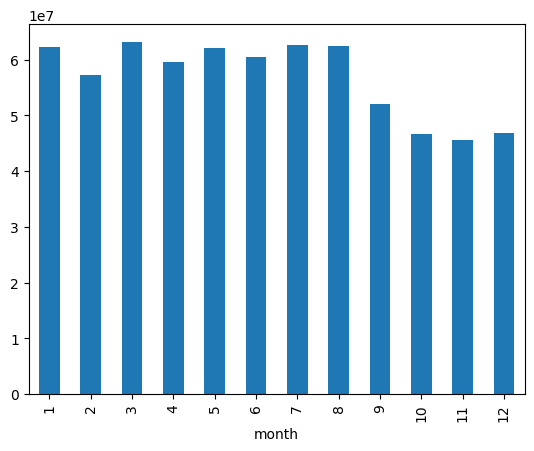

In [23]:
monthly_sales = df.groupby('month')['total_purchase_amount'].sum()

monthly_sales.plot(kind='bar')

In [24]:
df.groupby('year')['total_purchase_amount'].sum()

year
2020    185276174
2021    182843403
2022    182925502
2023    130297604
Name: total_purchase_amount, dtype: int64

In [25]:
yearly_sales = df.groupby('year')['total_purchase_amount'].sum().sort_values(ascending=False)
yearly_sales

year
2020    185276174
2022    182925502
2021    182843403
2023    130297604
Name: total_purchase_amount, dtype: int64

In [26]:
df.groupby('year')['customer_id'].count()

year
2020    68045
2021    67099
2022    67169
2023    47687
Name: customer_id, dtype: int64

In [27]:
df.groupby('year')['total_purchase_amount'].mean()

year
2020    2722.847733
2021    2724.979553
2022    2723.361997
2023    2732.350620
Name: total_purchase_amount, dtype: float64

In [28]:
df.groupby('year')['quantity'].sum()

year
2020    204199
2021    200525
2022    201806
2023    143194
Name: quantity, dtype: int64

In [29]:
df['year'].value_counts()

year
2020    68045
2022    67169
2021    67099
2023    47687
Name: count, dtype: int64

In [30]:
df[['customer_age', 'age']].head()

,customer_age,age
0,37,37
1,37,37
2,37,37
3,37,37
4,49,49


In [31]:
(df['customer_age'] == df['age']).all()

np.True_

In [32]:
df.drop(columns=['customer_age'], inplace=True)

In [33]:
bins = [18, 25, 35, 45, 60, 100]
labels = ['18-25', '26-35', '36-45', '46-60', '60+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [34]:
age_revenue = df.groupby('age_group')['total_purchase_amount'].sum().sort_values(ascending=False)
age_revenue

C:\Users\Anurang\AppData\Local\Temp\ipykernel_5004\1906287284.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_revenue = df.groupby('age_group')['total_purchase_amount'].sum().sort_values(ascending=False)


age_group
46-60    194604587
60+      133852202
36-45    127912392
26-35    124568897
18-25     87307757
Name: total_purchase_amount, dtype: int64

<Axes: xlabel='age_group'>

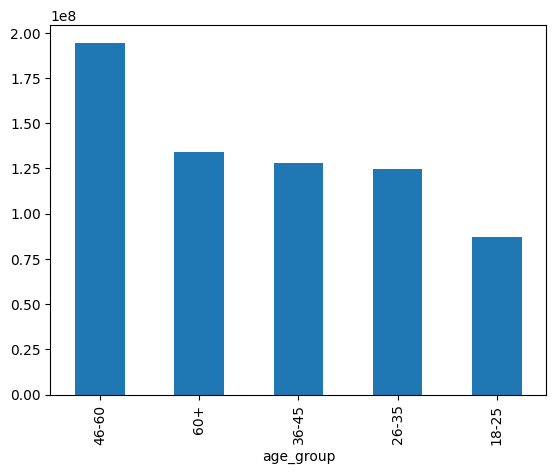

In [35]:
age_revenue.plot(kind='bar')

In [36]:
df.groupby('age_group')['total_purchase_amount'].mean().sort_values(ascending=False)

C:\Users\Anurang\AppData\Local\Temp\ipykernel_5004\2612271895.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['total_purchase_amount'].mean().sort_values(ascending=False)


age_group
60+      2831.712158
46-60    2768.595632
36-45    2710.812360
26-35    2655.713491
18-25    2618.237780
Name: total_purchase_amount, dtype: float64

In [37]:
df['age_group'].value_counts()

age_group
46-60    70290
60+      47269
36-45    47186
26-35    46906
18-25    33346
Name: count, dtype: int64

In [38]:
age_revenue

age_group
46-60    194604587
60+      133852202
36-45    127912392
26-35    124568897
18-25     87307757
Name: total_purchase_amount, dtype: int64

In [39]:
df.groupby('age_group')['churn'].mean()

C:\Users\Anurang\AppData\Local\Temp\ipykernel_5004\3219826084.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['churn'].mean()


age_group
18-25    0.206322
26-35    0.195988
36-45    0.197198
46-60    0.200199
60+      0.196598
Name: churn, dtype: float64

In [40]:
df.groupby('age_group')['total_purchase_amount'].mean().sort_values(ascending=False)

C:\Users\Anurang\AppData\Local\Temp\ipykernel_5004\2612271895.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['total_purchase_amount'].mean().sort_values(ascending=False)


age_group
60+      2831.712158
46-60    2768.595632
36-45    2710.812360
26-35    2655.713491
18-25    2618.237780
Name: total_purchase_amount, dtype: float64

In [41]:
df[df['age_group'] == '46-60'].groupby('payment_method')['customer_id'].count()

payment_method
Cash           14150
Credit Card    28130
Crypto          7013
PayPal         20997
Name: customer_id, dtype: int64

In [42]:
df[df['age_group'] == '46-60'].groupby('returns')['customer_id'].count()

returns
0.0    28539
1.0    28223
Name: customer_id, dtype: int64

In [43]:
df.groupby('age_group')['churn'].mean().sort_values(ascending=False)

C:\Users\Anurang\AppData\Local\Temp\ipykernel_5004\3799857883.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['churn'].mean().sort_values(ascending=False)


age_group
18-25    0.206322
46-60    0.200199
36-45    0.197198
60+      0.196598
26-35    0.195988
Name: churn, dtype: float64

In [44]:
df.groupby('age_group').agg({
    'total_purchase_amount': 'sum',
    'churn': 'mean'
}).sort_values(by='total_purchase_amount', ascending=False)

C:\Users\Anurang\AppData\Local\Temp\ipykernel_5004\1991638063.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group').agg({


,total_purchase_amount,churn
age_group,,
46-60,194604587,0.200199
60+,133852202,0.196598
36-45,127912392,0.197198
26-35,124568897,0.195988
18-25,87307757,0.206322


In [45]:
analysis_date = df['purchase_date'].max()
analysis_date

Timestamp('2023-09-15 12:24:08')

In [46]:
rfm = df.groupby('customer_id').agg({
    'purchase_date': lambda x: (analysis_date - x.max()).days,  # Recency
    'customer_id': 'count',                                    # Frequency
    'total_purchase_amount': 'sum'                              # Monetary
})

rfm.columns = ['recency', 'frequency', 'monetary']
rfm.head()

,recency,frequency,monetary
customer_id,,,
1,57,1,3491
2,298,3,7988
3,88,8,22587
4,126,4,8715
5,170,8,12524


In [47]:
rfm.describe()

,recency,frequency,monetary
count,49673.000000,49673.000000,49673.000000
mean,260.424979,5.032915,13716.559962
std,246.024001,2.206427,6840.208557
min,0.000000,1.000000,110.000000
25%,77.000000,3.000000,8719.000000
50%,184.000000,5.000000,13026.000000
75%,368.000000,6.000000,17966.000000
max,1352.000000,17.000000,55339.000000


In [48]:
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['monetary'], 5, labels=[1,2,3,4,5])

In [49]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [50]:
def segment_customer(row):
    if row['RFM_Score'] == '555':
        return 'Champions'
    elif row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Loyal Customers'
    elif row['R_score'] <= 2 and row['F_score'] <= 2:
        return 'At Risk'
    else:
        return 'Others'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

In [51]:
rfm.dtypes

recency         int64
frequency       int64
monetary        int64
R_score      category
F_score      category
M_score      category
RFM_Score      object
segment        object
dtype: object

In [52]:
rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

In [53]:
rfm['segment'].value_counts()

segment
Others             27984
At Risk            11115
Loyal Customers     8300
Champions           2274
Name: count, dtype: int64

In [54]:
import pandas as pd

snapshot_date = df['purchase_date'].max() + pd.Timedelta(days=1)

In [55]:
rfm = df.groupby('customer_id').agg({
    'purchase_date': lambda x: (snapshot_date - x.max()).days,
    'customer_id': 'count',
    'total_purchase_amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.reset_index(inplace=True)

In [56]:
rfm.head()

,customer_id,Recency,Frequency,Monetary
0,1,58,1,3491
1,2,299,3,7988
2,3,89,8,22587
3,4,127,4,8715
4,5,171,8,12524


In [57]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])

In [58]:
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 
                         5, labels=[1,2,3,4,5])

In [59]:
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [60]:
rfm[['R_score','F_score','M_score']] = rfm[['R_score','F_score','M_score']].astype(int)

In [61]:
rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) +
    rfm['F_score'].astype(str) +
    rfm['M_score'].astype(str)
)

In [62]:
def segment_customer(row):
    if row['R_score'] >= 4 and row['F_score'] >= 4 and row['M_score'] >= 4:
        return 'Champions'
    elif row['R_score'] >= 4 and row['F_score'] >= 3:
        return 'Loyal Customers'
    elif row['R_score'] >= 3 and row['F_score'] >= 2:
        return 'Potential Loyalist'
    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return 'At Risk'
    elif row['R_score'] == 1:
        return 'Lost Customers'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [63]:
rfm['Segment'].value_counts()

Segment
Potential Loyalist    11700
Champions              8739
At Risk                8711
Others                 7847
Lost Customers         6845
Loyal Customers        5831
Name: count, dtype: int64

In [64]:
segment_analysis = rfm.groupby('Segment').agg({
    'customer_id':'count',
    'Monetary':'sum'
}).sort_values(by='Monetary', ascending=False)

segment_analysis

,customer_id,Monetary
Segment,,
Champions,8739,190379607
Potential Loyalist,11700,166872418
At Risk,8711,140701477
Loyal Customers,5831,75743829
Others,7847,59244439
Lost Customers,6845,48400913


In [65]:
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Segment,,,
At Risk,411.502583,5.942027,16152.161290
Champions,61.306557,7.647557,21785.056299
Lost Customers,710.376041,2.596494,7070.988020
Loyal Customers,64.281598,5.283142,12989.852341
Others,233.050593,2.768064,7549.947623
Potential Loyalist,153.787009,5.222821,14262.599829
